# Exact Random-Guesser Distributions

No simulation is needed. TF and C15 are binomial. C25 uses a partial-credit per-question distribution: 10 points for two correct choices, 5 points for exactly one correct choice, and 0 points otherwise. The total score distribution is the convolution of the exact score distributions.


In [5]:
from math import comb, sqrt

TOTAL_SCORE = 440
PASSING_SCORE = int(0.70 * TOTAL_SCORE)

tf = {"max_score": 140, "mean": 70.0, "std": sqrt(70 * 1/2 * 1/2) * 2}
c15 = {"max_score": 150, "mean": 15 * 1/5 * 10, "std": sqrt(15 * 1/5 * 4/5) * 10}

# For C25, choosing 2 from 5 gives 10 possible pairs.
# Fully correct: 1 pair. Half-correct: choose 1 correct and 1 wrong = 2 * 3 = 6 pairs.
c25_probs = {0: 3/10, 5: 6/10, 10: 1/10}
c25_mean_one = sum(score * p for score, p in c25_probs.items())
c25_second_moment_one = sum(score**2 * p for score, p in c25_probs.items())
c25 = {
    "max_score": 150,
    "mean": 15 * c25_mean_one,
    "std": sqrt(15 * (c25_second_moment_one - c25_mean_one**2)),
}

question_types = {"TF": tf, "C15": c15, "C25": c25}
total_mean = sum(q["mean"] for q in question_types.values())
total_std = sqrt(sum(q["std"] ** 2 for q in question_types.values()))

for name, q in question_types.items():
    print(f"{name}: mean={q['mean']:.2f}, std={q['std']:.2f}, relative={q['mean'] / q['max_score'] * 100:.2f}% +- {q['std'] / q['max_score'] * 100:.2f}%")
print(f"Total: mean={total_mean:.2f}, std={total_std:.2f}, relative={total_mean / TOTAL_SCORE * 100:.2f}% +- {total_std / TOTAL_SCORE * 100:.2f}%")
print(f"Passing score: {PASSING_SCORE}")


TF: mean=70.00, std=8.37, relative=50.00% +- 5.98%
C15: mean=30.00, std=15.49, relative=20.00% +- 10.33%
C25: mean=60.00, std=11.62, relative=40.00% +- 7.75%
Total: mean=160.00, std=21.10, relative=36.36% +- 4.79%
Passing score: 308


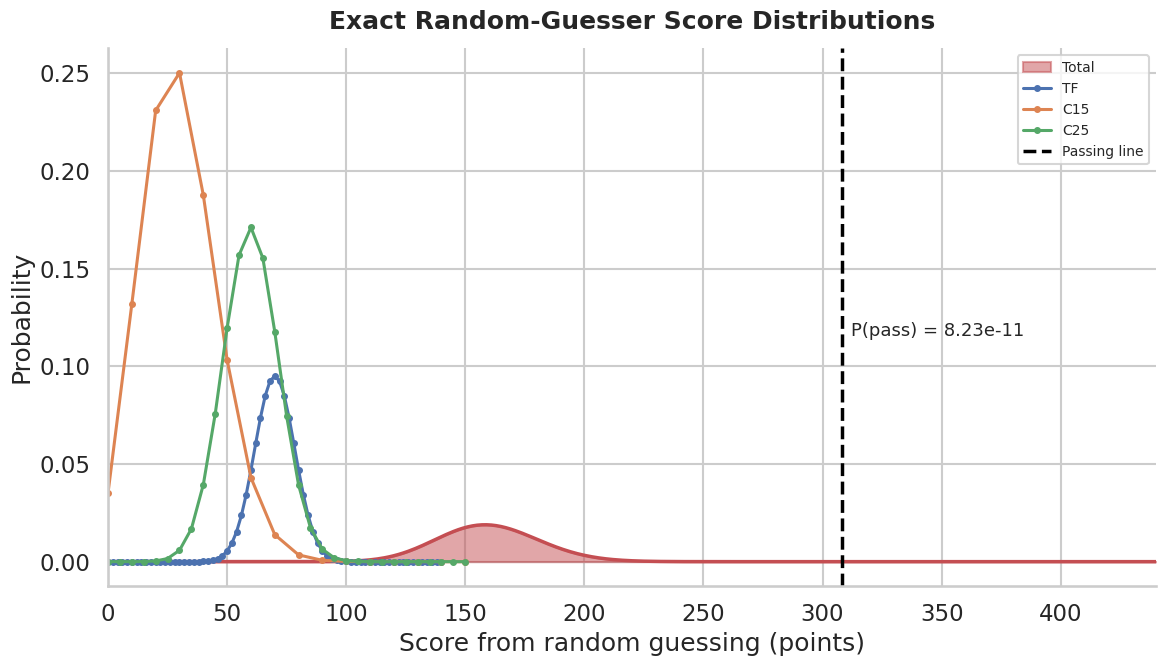

Probability of passing by pure random guessing: 8.225771649114e-11


In [6]:
from math import comb, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

TOTAL_SCORE = 440
PASSING_SCORE = int(0.70 * TOTAL_SCORE)
output_path = Path("../images/random_guesser_question_type_distributions.png")

def binomial_score_pmf(n, p, points):
    pmf = np.zeros(n * points + 1)
    for k in range(n + 1):
        pmf[k * points] = comb(n, k) * p**k * (1 - p)**(n - k)
    return pmf

def repeated_question_pmf(single_question_pmf, n):
    total = np.array([1.0])
    for _ in range(n):
        total = np.convolve(total, single_question_pmf)
    return total

tf_pmf = binomial_score_pmf(70, 1/2, 2)
c15_pmf = binomial_score_pmf(15, 1/5, 10)

# C25 partial credit: 0 points with probability 3/10, 5 points with 6/10, 10 points with 1/10.
c25_single = np.zeros(11)
c25_single[0] = 3/10
c25_single[5] = 6/10
c25_single[10] = 1/10
c25_pmf = repeated_question_pmf(c25_single, 15)

question_types = {
    "TF": {"pmf": tf_pmf, "mean": 70.0, "std": sqrt(70 * 1/2 * 1/2) * 2, "color": "#4C72B0"},
    "C15": {"pmf": c15_pmf, "mean": 15 * 1/5 * 10, "std": sqrt(15 * 1/5 * 4/5) * 10, "color": "#DD8452"},
}
c25_mean_one = 0 * 3/10 + 5 * 6/10 + 10 * 1/10
c25_second_moment_one = 0**2 * 3/10 + 5**2 * 6/10 + 10**2 * 1/10
question_types["C25"] = {"pmf": c25_pmf, "mean": 15 * c25_mean_one, "std": sqrt(15 * (c25_second_moment_one - c25_mean_one**2)), "color": "#55A868"}

total_pmf = np.convolve(np.convolve(tf_pmf, c15_pmf), c25_pmf)
total_scores = np.arange(len(total_pmf))
pass_probability = total_pmf[PASSING_SCORE:].sum()
total_mean = sum(q["mean"] for q in question_types.values())
total_std = sqrt(sum(q["std"] ** 2 for q in question_types.values()))

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(total_scores, total_pmf, color="#C44E52", alpha=0.5, label="Total")
ax.plot(total_scores, total_pmf, color="#C44E52", linewidth=2.5)

for name, q in question_types.items():
    scores = np.nonzero(q["pmf"])[0]
    probs = q["pmf"][scores]
    ax.plot(scores, probs, marker="o", linewidth=2.2, markersize=4, color=q["color"], label=name)

ax.axvline(PASSING_SCORE, color="black", linestyle="--", linewidth=2.5, label="Passing line")
ax.text(PASSING_SCORE + 4, ax.get_ylim()[1] * 0.45, f"P(pass) = {pass_probability:.2e}", ha="left", va="center", fontsize=13)
ax.set_title("Exact Random-Guesser Score Distributions", weight="bold", pad=14)
ax.set_xlabel("Score from random guessing (points)")
ax.set_ylabel("Probability")
ax.set_xlim(0, TOTAL_SCORE)
ax.legend(fontsize=10, frameon=True, loc="upper right")
sns.despine()
fig.tight_layout()
fig.savefig(output_path, dpi=220)
plt.show()
print(f"Probability of passing by pure random guessing: {pass_probability:.12e}")
